# ACE and Adult Outcome Aanalysis

This project explores relationships between adverse Childhood Experiences (ACEs) and adult outcomes using CDC BRFSS survey data.

The analysis focuses on:
- Childhood household drug exposure
- Childhood household alocohol exposure
- Mental health outcomes 
- Educational attainment
- Income category 
- Employment/workforce participation

The goal is to identify patterns and possible associations between childhood adversity and adult socioeconomic and health outcomes.

In [1]:
!pip install pyreadstat==1.2.3

## 1. Load Dataset

The dataset was loaded from the 2021 CDC BRFSS SAS Transport file. Each row represents one survey respondent, and each colum represents a survey variable.

In [2]:
import pandas as pd

In [3]:
import pyreadstat

In [4]:
df, meta = pyreadstat.read_xport("/Users/renoodle/Desktop/ace_dataset.XPT")

In [5]:
df.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_FRTRES1,_VEGRES1,_FRUTSU1,_VEGESU1,_FRTLT1A,_VEGLT1A,_FRT16A,_VEG23A,_FRUITE1,_VEGETE1
0,1.0,1.0,01192021,01,19,2021,1100.0,2021000001,2.021000e+09,1.0,...,1.0,1.0,100.0,214.0,1.0,1.0,1.0,1.0,0.0,0.0
1,1.0,1.0,01212021,01,21,2021,1100.0,2021000002,2.021000e+09,1.0,...,1.0,1.0,100.0,128.0,1.0,1.0,1.0,1.0,0.0,0.0
2,1.0,1.0,01212021,01,21,2021,1100.0,2021000003,2.021000e+09,1.0,...,1.0,1.0,100.0,71.0,1.0,2.0,1.0,1.0,0.0,0.0
3,1.0,1.0,01172021,01,17,2021,1100.0,2021000004,2.021000e+09,1.0,...,1.0,1.0,114.0,165.0,1.0,1.0,1.0,1.0,0.0,0.0
4,1.0,1.0,01152021,01,15,2021,1100.0,2021000005,2.021000e+09,1.0,...,1.0,1.0,100.0,258.0,1.0,1.0,1.0,1.0,0.0,0.0


In [6]:
[col for col in df.columns if 'ACE' in col.upper()]

['ACEDEPRS',
 'ACEDRINK',
 'ACEDRUGS',
 'ACEPRISN',
 'ACEDIVRC',
 'ACEPUNCH',
 'ACEHURT1',
 'ACESWEAR',
 'ACETOUCH',
 'ACETTHEM',
 'ACEHVSEX',
 'ACEADSAF',
 'ACEADNED',
 '_IMPRACE',
 '_CRACE1',
 '_CPRACE1',
 '_PRACE1',
 '_MRACE1',
 '_RACE',
 '_RACEG21',
 '_RACEGR3',
 '_RACEPRV']

## 2. Variable Exploration

Relevant variables were identified for ACE exposure, mental health, education, income, and employment outcomes.

In [7]:
[col for col in df.columns if 'MENT' in col.upper()]

['MENTHLTH', '_MENT14D']

In [8]:
[col for col in df.columns if 'DEPR' in col.upper()]

['ACEDEPRS']

In [9]:
[col for col in df.columns if 'EDU' in col.upper()]

['ARTHEDU', 'EDUCA', 'DIABEDU', '_EDUCAG']

In [10]:
[col for col in df.columns if 'INCOME' in col.upper()]

['INCOME3']

In [11]:
[col for col in df.columns if 'EMP' in col.upper()]

['EMPLOY1']

In [12]:
df['MENTHLTH'].value_counts()

88.0    271161
30.0     24953
2.0      22717
5.0      19130
3.0      14567
10.0     14554
15.0     13475
1.0      13091
20.0      7993
7.0       7428
4.0       7419
77.0      5723
25.0      2954
14.0      2722
6.0       2227
99.0      2192
8.0       1565
12.0      1082
28.0       819
21.0       516
29.0       400
18.0       289
9.0        252
16.0       230
27.0       208
17.0       198
13.0       160
22.0       159
11.0       134
24.0       128
26.0       116
23.0       102
19.0        27
Name: MENTHLTH, dtype: int64

In [13]:
df['ACEDEPRS'].value_counts()

2.0    46934
1.0    10326
9.0     1021
7.0      482
Name: ACEDEPRS, dtype: int64

In [14]:
[col for col in df.columns if 'ACE' in col.upper()]

['ACEDEPRS',
 'ACEDRINK',
 'ACEDRUGS',
 'ACEPRISN',
 'ACEDIVRC',
 'ACEPUNCH',
 'ACEHURT1',
 'ACESWEAR',
 'ACETOUCH',
 'ACETTHEM',
 'ACEHVSEX',
 'ACEADSAF',
 'ACEADNED',
 '_IMPRACE',
 '_CRACE1',
 '_CPRACE1',
 '_PRACE1',
 '_MRACE1',
 '_RACE',
 '_RACEG21',
 '_RACEGR3',
 '_RACEPRV']

In [15]:
df.groupby('ACEDRINK') ['MENTHLTH'].mean()

ACEDRINK
1.0    52.345428
2.0    63.386148
7.0    57.054187
9.0    62.630817
Name: MENTHLTH, dtype: float64

In [16]:
df['MENTHLTH'].value_counts().sort_index()

1.0      13091
2.0      22717
3.0      14567
4.0       7419
5.0      19130
6.0       2227
7.0       7428
8.0       1565
9.0        252
10.0     14554
11.0       134
12.0      1082
13.0       160
14.0      2722
15.0     13475
16.0       230
17.0       198
18.0       289
19.0        27
20.0      7993
21.0       516
22.0       159
23.0       102
24.0       128
25.0      2954
26.0       116
27.0       208
28.0       819
29.0       400
30.0     24953
77.0      5723
88.0    271161
99.0      2192
Name: MENTHLTH, dtype: int64

## 3. Data Cleaning 

BRFSS survey data uses coded values such as 77, 88, and 99 for responses like "Don't know," "None," or "Refused." These values were cleaned before analysis to avoid inaccurate calculations.

In [17]:
df['MENTHLTH_CLEAN'] = df['MENTHLTH'].replace({
    77: None,
    99: None,
    88: 0
})

In [18]:
df['INCOME3_CLEAN'] = df['INCOME3'].replace({
    77: None,
    99: None
})

In [19]:
df['EDUCA_CLEAN'] = df['EDUCA'].replace({
    9: None
})

In [20]:
df['EMPLOY1_CLEAN'] = df['EMPLOY1'].replace({
    7: None,
    9: None
})

## Data Cleaning and Preparation

In [21]:
df['MENTHLTH'].unique()

array([10., 88.,  5., 25., 15., 77., 14.,  2.,  3.,  7.,  1., 30., 20.,
        8.,  4., nan, 99., 21., 28., 24.,  6., 12., 22., 27.,  9., 18.,
       13., 17., 16., 19., 29., 11., 23., 26.])

In [22]:
df['MENTHLTH'].describe()

count    438691.000000
mean         59.923347
std          37.472680
min           1.000000
25%          15.000000
50%          88.000000
75%          88.000000
max          99.000000
Name: MENTHLTH, dtype: float64

In [23]:
df['MENTHLTH_CLEAN'].describe()

count    430776.000000
mean          4.104189
std           8.165460
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max          30.000000
Name: MENTHLTH_CLEAN, dtype: float64

In [24]:
df['EMPLOY1_CLEAN'].unique()

array([None, 8.0, 2.0, 5.0, 1.0, 6.0, 4.0, nan, 3.0], dtype=object)

## 4. Household Alcohol  Exposure and Mental Health

This section compares average poor mental health days among respondents with and without childhood alcohol exposure. 

In [25]:
df.groupby('ACEDRINK')['MENTHLTH_CLEAN'].mean()

ACEDRINK
1.0    6.065763
2.0    3.259101
7.0    6.547872
9.0    5.106243
Name: MENTHLTH_CLEAN, dtype: float64

In [26]:
clean_df = df[df['ACEDRINK'].isin([1, 2])]

In [27]:
clean_df.groupby('ACEDRINK')['MENTHLTH_CLEAN'].mean()

ACEDRINK
1.0    6.065763
2.0    3.259101
Name: MENTHLTH_CLEAN, dtype: float64

<AxesSubplot:xlabel='ACEDRINK'>

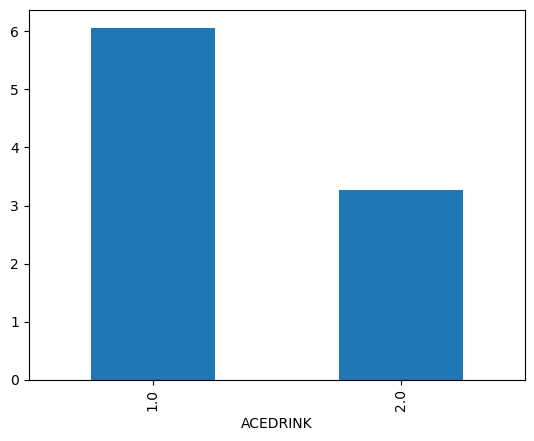

In [28]:
clean_df.groupby('ACEDRINK')['MENTHLTH_CLEAN'].mean().plot(kind='bar')

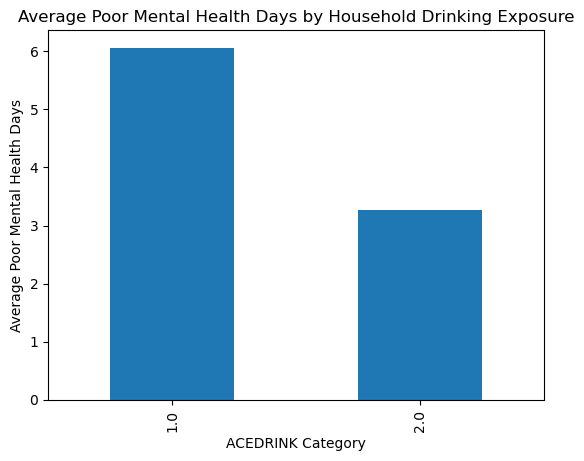

In [29]:
import matplotlib.pyplot as plt

clean_df.groupby('ACEDRINK')['MENTHLTH_CLEAN'].mean().plot(kind='bar')

plt.title('Average Poor Mental Health Days by Household Drinking Exposure')
plt.xlabel('ACEDRINK Category')
plt.ylabel('Average Poor Mental Health Days')
plt.show()

Respondents reporting childhood household alcohol exposure showed higher average poor mental health days compared to respondents without reported exposure. This suggests a possible association between childhood household alcohol exposure and adult mental health outcomes.

## 5. Household Drug Exposure and Income Category

This section compares income category averages between respondents with and without childhood household drug exposure.

In [30]:
[col for col in df.columns if 'INCOME' in col.upper()]

['INCOME3', 'INCOME3_CLEAN']

In [31]:
[col for col in df.columns if 'DRUG' in col.upper()]

['ACEDRUGS']

In [32]:
[col for col in df.columns if 'SMOKE' in col.upper()]

['SMOKE100', '_SMOKER3']

In [33]:
[col for col in df.columns if 'ALCO' in col.upper()]

['_DUALCOR']

In [34]:
clean_df.groupby('ACEDRUGS')['INCOME3'].mean()

ACEDRUGS
1.0    18.205033
2.0    22.963160
7.0    29.101695
9.0    34.783333
Name: INCOME3, dtype: float64

In [35]:
df['INCOME3'].value_counts().sort_index()

1.0     10878
2.0     11530
3.0     14960
4.0     21071
5.0     43893
6.0     48339
7.0     59408
8.0     47838
9.0     47642
10.0    19769
11.0    18952
77.0    36138
99.0    49428
Name: INCOME3, dtype: int64

In [36]:
clean_df = df[df['ACEDRUGS'].isin([1, 2])]

In [37]:
clean_df.groupby('ACEDRUGS')['INCOME3_CLEAN'].mean()

ACEDRUGS
1.0    6.412432
2.0    6.716781
Name: INCOME3_CLEAN, dtype: float64

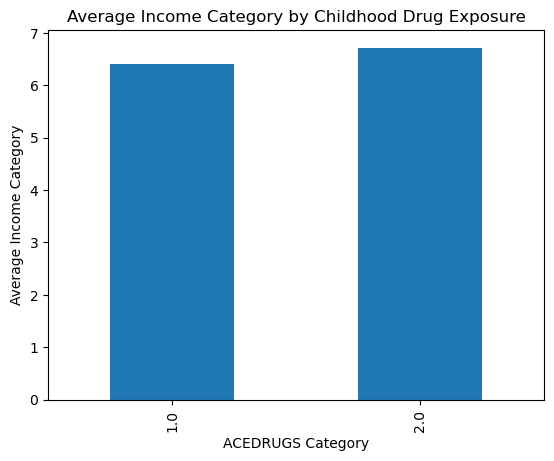

In [38]:
import matplotlib.pyplot as plt

df[df['ACEDRUGS'].isin([1,2])].groupby('ACEDRUGS')['INCOME3_CLEAN'].mean().plot(kind='bar')

plt.title('Average Income Category by Childhood Drug Exposure')
plt.xlabel('ACEDRUGS Category')
plt.ylabel('Average Income Category')
plt.show()

The income category analysis showed minimal difference between respondents with and without childhood household drug exposure. This suggests that, in this dataset, household drug exposure did not show a strong direct relationship with income category.

## 6. Household Drug Exposure and Educational Attainment

This section compares the average education attainment category between respondents with and without childhood household drug exposure.

In [39]:
df.groupby('ACEDRUGS')['EDUCA'].mean()

ACEDRUGS
1.0    4.865392
2.0    5.032345
7.0    4.849123
9.0    5.147864
Name: EDUCA, dtype: float64

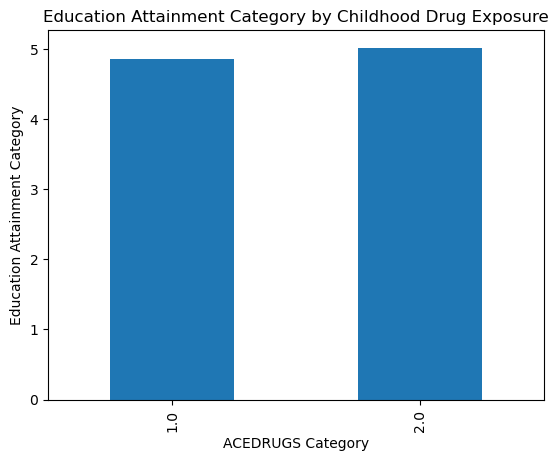

In [40]:
import matplotlib.pyplot as plt

df[df['ACEDRUGS'].isin([1,2])].groupby('ACEDRUGS')['EDUCA_CLEAN'].mean().plot(kind='bar')

plt.title('Education Attainment Category by Childhood Drug Exposure')
plt.xlabel('ACEDRUGS Category')
plt.ylabel('Education Attainment Category')
plt.show()

Respondents reporting childhood household drug exposure demonstrated slightly lower average educational attainment compared to respondents without reported exposure. While the difference was modest, the results suggest a possible negative relationship between childhood household drug exposure and educational outcomes.

## 7. Household Drug Exposure and Employment Outcomes

This section compares employment status distrinutions between respondents with and without childhood drug exposure.

In [41]:
[col for col in df.columns if 'EMP' in col.upper()]

['EMPLOY1', 'EMPLOY1_CLEAN']

In [42]:
[col for col in df.columns if 'WORK' in col.upper()]

['WORKCFS']

In [43]:
df['EMPLOY1'].value_counts().sort_index()

1.0    186076
2.0     37759
3.0     11406
4.0      9713
5.0     17579
6.0     10661
7.0    131546
8.0     25702
9.0      4663
Name: EMPLOY1, dtype: int64

In [44]:
# Were respondents exposed to household drug or alcohol abuse more likely to experience unemployment or
# reduced workforce participation?

In [45]:
df.groupby('ACEDRUGS')['EMPLOY1_CLEAN'].mean()

ACEDRUGS
1.0    2.484496
2.0    2.323792
7.0    2.697436
9.0    2.338596
Name: EMPLOY1_CLEAN, dtype: float64

In [46]:
pd.crosstab(df['ACEDRUGS'], df['EMPLOY1_CLEAN'], normalize='index') * 100

EMPLOY1_CLEAN,1.0,2.0,3.0,4.0,5.0,6.0,8.0
ACEDRUGS,,,,,,,
1.0,60.745047,11.111111,4.543497,4.220500,4.306632,3.574505,11.498708
2.0,63.058741,13.047622,2.754392,2.401754,6.156876,3.037138,9.543476
7.0,56.410256,9.743590,7.179487,3.589744,6.153846,4.102564,12.820513
9.0,62.807018,12.631579,3.684211,3.684211,3.859649,2.982456,10.350877


The normalized employment distribution showed modest differences between respondents with and without childhood household drug exposure. Respondents reporting exposure had slightly lower representation in the primary employment category and a higher percentage in the unable-to-work category, suggesting possible differences in workforce participation patterns.

In [47]:
analysis_df = df[[
    'MENTHLTH_CLEAN',
    'EDUCA_CLEAN',
    'INCOME3_CLEAN',
    'EMPLOY1_CLEAN',
    'ACEDRUGS',
    'ACEDRINK'
]]

In [48]:
analysis_df.corr()

,MENTHLTH_CLEAN,ACEDRUGS,ACEDRINK
MENTHLTH_CLEAN,1.000000,-0.022675,-0.038500
ACEDRUGS,-0.022675,1.000000,0.751109
ACEDRINK,-0.038500,0.751109,1.000000


## 8. Correlation Analysis

A correlation matrix was used to examine relationships between ACE exposure variable and outcome variables.

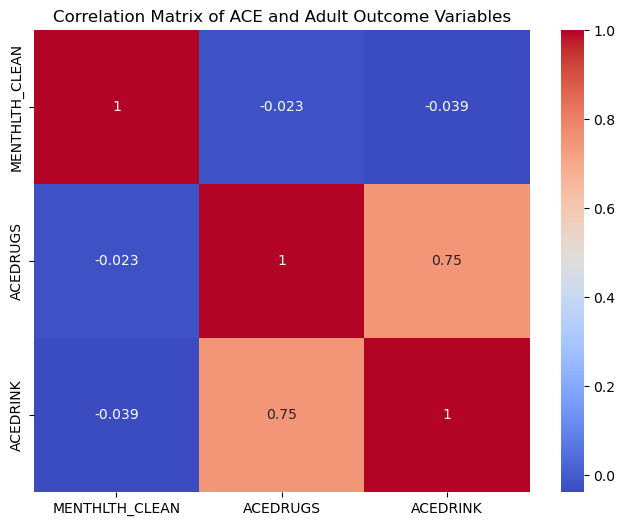

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = analysis_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix of ACE and Adult Outcome Variables')

plt.show()

The heatmap showed a strong relationship between childhood household drug exposure and household alcohol exposure. However, correlations between ACE exposure variables and adult mental health outcomes were weak, suggesting that additional social, economic, and environmental factors may influence long-term adult outcomes.

## 9. Conclusion 

This analysis identified several patterns between childhood adverse experiences and adult outcomes. Household alcohol exposure showed a clearer association with poor mental health days, while household drug exposure showed modest relationships with educational and employment outcomes. 
The stongest relationship identified was between childhood household drug exposure, suggesting these experiences may frequently occur together.
Overall, the findings suggest that ACE-related experiences may be associated with adult mental health, education, and workforce outcomes, though the relationships are complex and likely infuenced by additional factors.

In [50]:
project_df = df[[
    'MENTHLTH_CLEAN',
    'EDUCA_CLEAN',
    'INCOME3_CLEAN',
    'EMPLOY1_CLEAN',
    'ACEDRUGS',
    'ACEDRINK'
]]

project_df = project_df.dropna()
project_sample = project_df.sample(5000, random_state=42)
project_sample.to_csv('ace_project_sample.csv', index=False)